In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [296]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [297]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [298]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(df["Species"])
df["Species"] = label_encoder.fit_transform(df["Species"])

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [299]:
from sklearn.model_selection import train_test_split

df.drop(["Id"],axis=1,inplace = True)

X = df.drop(["Species"],axis=1,inplace = False)
Y = df["Species"]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state = 0, test_size = 0.2)

print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("Y_train shape:",Y_train.shape)
print("Y_test shape:",Y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
Y_train shape: (120,)
Y_test shape: (30,)


In [300]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

svc = SVC()
accuracies = cross_val_score(estimator=svc, X = X_train, y = Y_train, cv = 5)
train_score = np.mean(accuracies)
    
svc.fit(X_train,Y_train)
test_score = svc.score(X_test,Y_test)

print("Train Score of Default Parameters:",train_score)
print("Test Score of Default Parameters:",test_score)

Train Score of Default Parameters: 0.9583333333333334
Test Score of Default Parameters: 1.0


------------

### Parameter C (Regularization)

**C** controls the trade-off between **maximum margin** and **classification accuracy**.

- **Small C:** Large margin, allows some misclassification, simpler model, may underfit.
- **Large C:** Small margin, fewer misclassifications, complex model, may overfit.

There is **no fixed value** for **C**. It is usually selected using **experimentation** or **GridSearchCV**.

### Effect of C

Choose the **C** value that gives the **highest cross-validation accuracy**.

[np.float64(0.36666666666666664), np.float64(0.8583333333333334), np.float64(0.9583333333333334), np.float64(0.95), np.float64(0.95)]


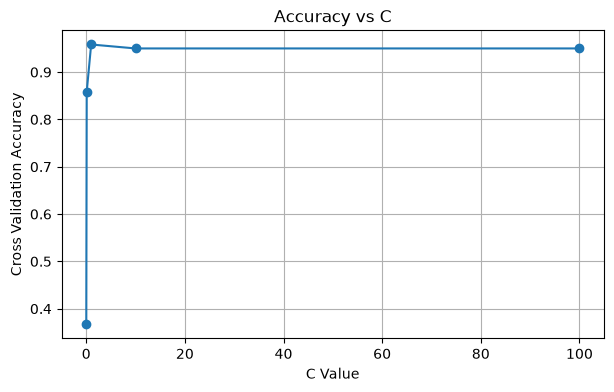

In [301]:
C_values = [0.01, 0.1, 1, 10, 100]
scores = []

for c in C_values:
    model = SVC(C=c)
    accuracy = cross_val_score(
        model,
        X_train,
        Y_train,
        cv=5,
        scoring='accuracy'
    )

    scores.append(accuracy.mean())

print(scores)

plt.figure(figsize=(7,4))
plt.plot(C_values, scores, marker='o')
plt.title("Accuracy vs C")
plt.xlabel("C Value")
plt.ylabel("Cross Validation Accuracy")
plt.grid(True)

plt.show()

### Understanding Kernel
The **kernel** determines the shape of the **decision boundary**.

Common kernels are:
- **linear**
- **poly**
- **rbf**
- **sigmoid**
The default kernel in **Scikit-learn** is **RBF**.

#### Comparing Kernels
Different kernels perform differently on different datasets. Select the one that gives the **best validation or cross-validation accuracy**.

[np.float64(0.95), np.float64(0.95), np.float64(0.9583333333333334), np.float64(0.36666666666666664)]


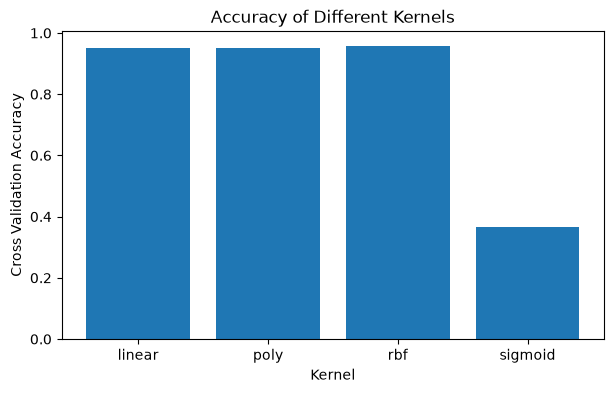

In [302]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

kernel_scores = []

for kernel in kernels:
    model = SVC(kernel=kernel)
    accuracy = cross_val_score(
        model,
        X_train,
        Y_train,
        cv=5,
        scoring='accuracy'
    )
    kernel_scores.append(accuracy.mean())

print(kernel_scores)

plt.figure(figsize=(7,4))
plt.bar(kernels, kernel_scores)
plt.title("Accuracy of Different Kernels")
plt.xlabel("Kernel")
plt.ylabel("Cross Validation Accuracy")

plt.show()

### Understanding Gamma

**Gamma** controls how much influence a single training sample has.

- **Small Gamma:** Smooth decision boundary, simpler model, may underfit.
- **Large Gamma:** Complex decision boundary, fits training data closely, may overfit.

Gamma is mainly used with:

- **RBF**
- **Polynomial**
- **Sigmoid** kernels

### Effect of Gamma

Choose the **gamma** value that gives the **best validation or cross-validation accuracy**.

[np.float64(0.9583333333333334), np.float64(0.9583333333333334), np.float64(0.925), np.float64(0.9583333333333334), np.float64(0.95)]


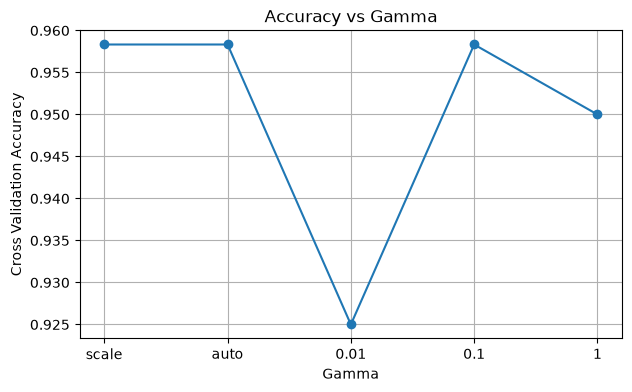

In [303]:
gamma_values = ['scale', 'auto', 0.01, 0.1, 1]
gamma_scores = []

for gamma in gamma_values:
    model = SVC(
        kernel='rbf',
        gamma=gamma,
        C=1
    )
    accuracy = cross_val_score(
        model,
        X_train,
        Y_train,
        cv=5,
        scoring='accuracy'
    )
    
    gamma_scores.append(accuracy.mean())
    
print(gamma_scores)

plt.figure(figsize=(7,4))
plt.plot(
    range(len(gamma_values)),
    gamma_scores,
    marker='o'
)
plt.xticks(
    range(len(gamma_values)),
    gamma_values
)
plt.title("Accuracy vs Gamma")
plt.xlabel("Gamma")
plt.ylabel("Cross Validation Accuracy")
plt.grid(True)

plt.show()

--------------

### Finding the Best Parameters using GridSearchCV

Instead of manually testing different values, we can use **GridSearchCV**.
GridSearchCV automatically tests different combinations of:
- C
- Kernel
- Gamma
and selects the combination that gives the highest cross-validation accuracy.

In [304]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.1,1,10,100],
    'kernel':['linear','rbf','poly'],
    'gamma':['scale','auto',0.01,0.1,1]
}

grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1

)

grid.fit(X_train, Y_train)

print("Best Parameters :", grid.best_params_)
print("Best Cross Validation Score :", grid.best_score_)

Best Parameters : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross Validation Score : 0.9583333333333334


--------------

### Train the Best SVM Model with Best Parameters

In [305]:
best_model = grid.best_estimator_
best_model.fit(X_train, Y_train)
y_pred = best_model.predict(X_test)

In [306]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Accuracy :", accuracy_score(Y_test, y_pred))
print()
print(confusion_matrix(Y_test, y_pred))
print()
print(classification_report(Y_test, y_pred))

Accuracy : 1.0

[[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

